# TensorFlow Keras. Прогнозирование функций

[1] <span>&#9757;&#128578;</span> Данное занятие разработано на основе русскоязычной книги – [21] в списке источников и литературы.

## Цели занятия

Изучение основ работы с библиотекой для машинного обучения `TensorFlow` и надстройкой над ней – `Keras`. Получение базовых знаний о нейронных сетях и практических навыков работы с ними. Решение простейших математических задач при помощи нейронных сетей.

## Порядок выполнения работы

### Введение. Изучение основ работы с TensorFlow Keras

#### TensorFlow

`TensorFlow` – открытая программная библиотека для машинного обучения, разработанная компанией Google для решения задач построения и тренировки нейронной сети с целью автоматического нахождения и классификации образов. Применяется как для исследований, так и для разработки собственных продуктов Google. Основной `API` (англ. application programming interface, программный интерфейс приложения) для работы с библиотекой реализован на языке `Python`, также существуют реализации для языков `C#`, `C++`, `Java`, `JavaScript` и другие.

Работа c `TensorFlow` строится вокруг построения и выполнения графа вычислений. Граф вычислений – это конструкция, которая описывает то, каким образом будут проводиться вычисления. В классическом императивном программировании пишется код, который выполняется построчно. В `TensorFlow` привычный императивный подход к программированию необходим только для вспомогательных целей. Основа `TensorFlow` – это создание структуры, задающей порядок вычислений. Программы естественным образом структурируются на две части – составление графа вычислений и выполнение вычислений в созданных структурах.

В `TensorFlow` граф состоит из плейсхолдеров, переменных и операций. Из этих элементов можно собрать граф, в котором будут вычисляться тензоры. Тензоры — многомерные массивы, они служат «топливом» для графа. Тензором может быть как отдельное число, вектор признаков из решаемой задачи или изображение, так и целый пакетный файл описаний объектов или массив из изображений. Вместо одного объекта мы можем передать в граф массив объектов, и для него будет вычислен массив ответов.

В `TensorFlow` тензоры являются многомерными массивами, которые текут (на англ. flow) через узлы графа. Узлами графа являются операции (см. Рис. 1).

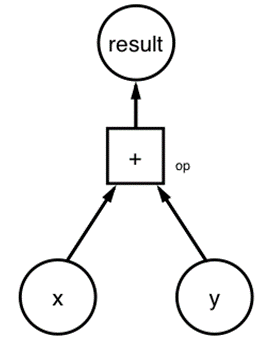

Рис. 1. Граф, выполняющий операцию X+Y

#### Keras

Keras – открытая нейросетевая библиотека, написанная на языке `Python`, представляющая собой надстройку над фреймворками `Deeplearning4j`, `TensorFlow` и `Theano` (см. рисунок)[2], нацелена на оперативную работу с сетями глубинного обучения, при этом спроектирована так, чтобы быть компактной, модульной и расширяемой. Эта библиотека содержит многочисленные реализации широко применяемых строительных блоков нейронных сетей, таких как слои, целевые и передаточные функции, оптимизаторы, и множество инструментов для упрощения работы с изображениями и текстом. Позволяет работать с TensorFlow не как с графами, а как с абстракциями – т.е. с нейронными сетями.

[2] <span>&#9757;&#128578;</span> Изначально `Keras` был построен «вокруг» библиотеки `Theano`, затем поддерживал несколько бэкендов (`Theano`, `CNTK`, `MXNet`, `Tensorflow`), а начиная с 2020 года осталась возможна работа только с `Tensorflow`, так как теперь разработкой `Keras` занимается команда `Tensorflow` и `Keras` стал поставляться вместе с библиотекой `Tensorflow`. Но возможность использовать другие бэкенды («движки») сохраняется, если использовать `Keras` версий 2.3 и ниже (по состоянию на январь 2022г. актуальная версия `Keras` – 2.8).

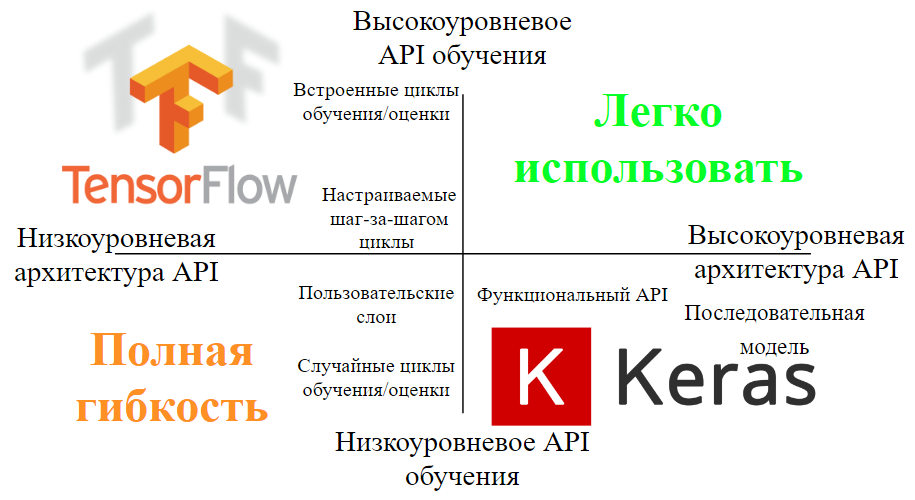

Рис. 2. `TensorFlow` с надстройкой `Keras`

#### Среды тензорных вычислений

`TensorFlow` способен выполнятся на следующих устройствах:

-   Персональных компьютерах общего назначения (возможна работа как на центральном, так и на графических процессорах);

-   Встраиваемых и мобильных системах (нативно на смартфонах с `ОС Android/IOS`, на одноплатных компьютерах c `Raspbian`, в веб браузере);

-   Специализированных тензорных процессорах (`TPU Google`, см. Рис. 3), которые `Google` предоставляет в формате облачной среды вычисления и доступ к которым очень прост даже для новичка – необходимо купить подписку и станет возможным обучать собственные модели на специализированном и предназначенном для этого оборудовании, имеющем наиболее высокую для этих задач производительность (подробнее по url: [<u>https://cloud.google.com/tpu/docs/system-architecture</u>](https://cloud.google.com/tpu/docs/system-architecture)).

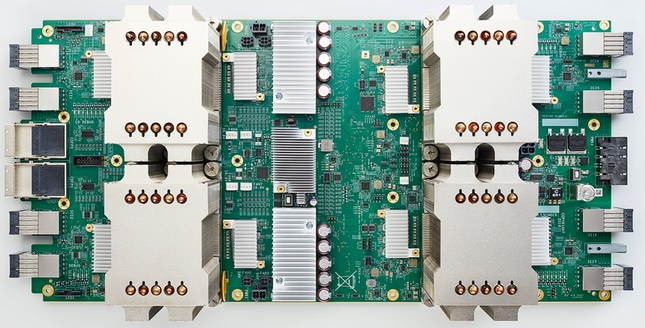

Рис. 3. Тензорный процессор Google

Требования `TensorFlow` (для `Python 3` версии[3]) к операционной системе:

[3] <span>&#9757;&#128578;</span> Т.к. существуют реализации `TensorFlow` и для других языков программирования.

-   `Ubuntu` и `Debian` c ядром (`kernel)` версии 4.14 или выше (`64-bit`);

-   `macOS 10.12.6` или выше (`64-bit`, без поддержки GPU);

-   Windows 7 или выше (`64-bit`);

-   Raspbian 9.0 или выше.

### Пример 1. Y = 3X + 1

Приступим к реализации простейшей нейронной сети `TensorFlow Keras` для решения простейшей математической задачи. Рассмотрим следующие наборы чисел, представленные в таблице ниже (Таблица 1):

Таблица 1. Обучающая выборка для Y = 3X + 1

| X: | -1 | 0 | 1 | 2 | 3  | 4  |
|----|----|---|---|---|----|----|
| Y: | -2 | 1 | 4 | 7 | 10 | 13 |

Данные пары значений соответствуют результату уравнения Y = 3X + 1 и они необходимы нам для обучения нейронной сети, которую нам предстоит написать.

Начнем с подключения необходимых библиотек. Здесь мы импортируем `TensorFlow` и называем его «`tf`» для простоты использования. Далее мы импортируем библиотеку с именем «`numpy`», которая помогает нам легко и быстро представлять наши данные в виде списков. Структура для определения нейронной сети как набора последовательных слоев называется «`keras`», поэтому мы импортируем её тоже.

In [ ]:
import tensorflow as tf  #библиотека для машинного обучения
import numpy as np  #математическая библиотека (поддержка многомерных массивов и
                    #высокоуровневых математических функций над ними
from tensorflow import keras #библиотека высокоуровневого API для tensorflow и не только неё
from tensorflow.keras.utils import plot_model #утилита для визуализации полученной модели

print(tf.__version__)
print(keras.__version__)
print(np.__version__)

Далее мы создадим простейшую из возможных нейронных сетей. У неё будет 1 слой («`keras.layers.Dense()`» – добавление слоя), в котором – 1 нейрон (`units=1`), и входная в него величина имеет только размерность 1, т.е. на вход данного слоя приходит только одно значение (`input_shape=[1]` или `input_dim=1` («dim»–dimension, размерность).

#### Функции активации

Так же можно указать и функцию активации этого слоя «`activation='linear'`»`, но линейная функция активации является значением по умолчанию, поэтому не будем это отдельно указывать. Описание линейной функции и некоторых основных функций активации кратко изложено в таблице ниже (Таблица 2)[4], где: X – это входная переменная.

[4] <span>&#9757;&#128578;</span> Ознакомится с доступными функциями активации в полной мере или узнать, как создать свою собственную – можно в официальной документации (доступной по url: <u>https://keras.io/activations/</u>).

Таблица 2. Краткое описание основных доступных функций активации

<table>
<colgroup>
<col style="width: 50%" />
<col style="width: 8%" />
<col style="width: 29%" />
</colgroup>
<thead>
<tr class="header">
<th>Название функции</th>
<th>Область значений</th>
<th>Синтаксис</th>
</tr>
</thead>
<tbody>
<tr class="odd">
<td><p>Экспоненциальная линейная функция (англ. Exponential linear unit, ELU).</p>
<p><span class="math display">$$\text{SELU}(x) = \left\{ \begin{matrix}
\alpha(e^{x} - 1)\ \ \ \ \ x \leqslant \ 0 \\
x\ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ x > 0 \\
\end{matrix} \right.\ $$</span></p>
<p>где α =1,67326…</p>
<p>

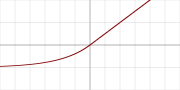
</p></td>
<td>(-α, ∞)</td>
<td>keras.activations.elu(x, alpha=1.0)</td>
</tr>
<tr class="even">
<td><p>Масштабированная экспоненциальная линейная функция (англ. Scaled exponential linear unit, SELU).</p>
<p>(25)</p>
<p><span class="math display">$$\text{SELU}(x) = \text{λ}\left\{ \begin{matrix}
\alpha(e^{x} - 1)\ \ \ \ \ x \leqslant \ 0 \\
x\ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ x > 0 \\
\end{matrix} \right.\ $$</span></p>
<p>или</p>
<p><span class="math display">SELU(<em>x</em>) = λ * (max(0,<em>x</em>)+min(0,<em>α</em>*(exp(<em>x</em>)−1)))</span></p>
<p>где λ =1,0507… и α =1,67326…</p>
<p>

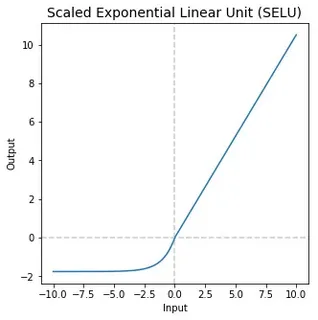

</p></td>
<td>(-αλ, ∞)</td>
<td>keras.activations.selu(x)</td>
</tr>
<tr class="odd">
<td><p>Выпрямитель или функция активации ReLU (Rectified Linear Unit) – является функцией активации, определяемой как положительная часть его аргумента</p>
<p><span class="math display"><em>R</em><em>e</em><em>L</em><em>U</em>(<em>x</em>) = (<em>x</em>)<sup>+</sup> = <em>m</em><em>a</em><em>x</em>(0,<em>x</em>) (26)</span></p>
<p>

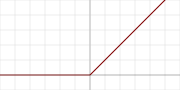

</p></td>
<td>[0, ∞)</td>
<td>keras.activations.relu(x)</td>
</tr>
<tr class="even">
<td><p>Линейный выпрямитель с «утечкой» (англ. Leaky rectified linear unit, Leaky ReLU) (27)</p>
<p><span class="math display">LeakyReLU(<em>x</em>) = max (0,<em>x</em>) + α * min (0,<em>x</em>)</span></p>
<p>или</p>
<p><span class="math display">$$\text{LeakyRELU}(x) = \left\{ \begin{matrix}
x, \ x \geq 0 \\
\text{α} \times x, \text{ иначе } \\
\end{matrix} \right.\ $$</span></p>
<p>где по умолчанию <span class="math inline">α =0,01</span>.</p>
<p>

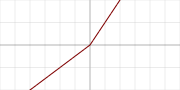

</p></td>
<td>(-∞, ∞)</td>
<td>keras.activations.relu(x, alpha=0.0, max_value=None, threshold=0.0)</td>
</tr>
<tr class="odd">
<td><p>Гиперболический тангенс (<span class="math inline">tanh </span>)</p>
<p><span class="math display">$$\tanh(x) = \frac{\exp(x) - exp( - x)}{\exp(x) + exp( - x)}\ (28)$$</span></p>
<p>

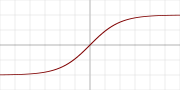

</p></td>
<td>(-1, 1)</td>
<td>keras.activations.tanh(x)</td>
</tr>
<tr class="even">
<td><p>Логистическая (сигмоида или Гладкая ступенька)</p>
<p><span class="math display">$$\text{s}\text{igmoid}(x) = \sigma(x) = \frac{1}{1 + exp( - x)}(29)$$</span></p>
<p>

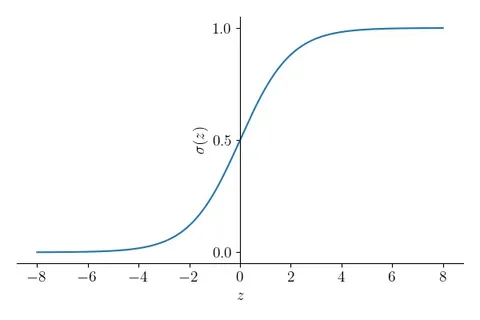

</p></td>
<td>(0, 1)</td>
<td>keras.activations.sigmoid(x)</td>
</tr>
<tr class="odd">
<td><span class="math display">linear(<em>x</em>) = <em>x</em> (30)</span></td>
<td>(-∞, ∞)</td>
<td>keras.activations.linear(x)</td>
</tr>
</tbody>
</table>

Финальный вид кода для создания описанной модели нейронной сети, выглядит так:

In [ ]:
#use_bias=True - использовать нейрон смещения (хотя он и так по умолчанию используется)
model = tf.keras.Sequential(
    [keras.layers.Dense(units=1, input_shape=[1], use_bias=True)])

Напишем код для компиляции нашей нейронной сети. Когда мы делаем это, мы должны указать 2 функции: «потери» и «оптимизатор».

Функция «потери» («`loss`») вычисляет разность «угаданных» (вычисленных) ответов с известными правильными ответами и измеряет, насколько точно произведено решение. Основываясь на результатах функции потерь, `TensorFlow` «попытается» минимизировать потери используя заданный алгоритм оптимизации на каждом шаге обучения.

Укажем программе использовать «среднеквадратичную ошибку» («`mean_squared_error`») для потерь и «стохастический градиентный спуск» («`sgd`») для оптимизатора (список алгоритмов оптимизации доступен в официальной документации по url: [<u>https://keras.io/optimizers/</u>](https://keras.io/optimizers/)). Обычно используют именно эти установки параметров потерь и оптимизатора.

In [ ]:
model.compile(optimizer='sgd', loss='mean_squared_error')  

Далее мы создадим обучающую выборку для нашего уравнения при помощи библиотеки numpy, которая, как известно, предоставляет нам широкую функциональность по работе с массивами. Для этого используем функцию np.array:

In [ ]:
xs = np.array([-1.0, 0.0, 1.0, 2.0, 3.0, 4.0], dtype=float)  
ys = np.array([-2.0, 1.0, 4.0, 7.0, 10.0, 13.0], dtype=float)  

Код, необходимый для определения нейронной сети, написан. Теперь обучим нашу нейросеть. Процесс обучения нейронной сети, где она «изучает» отношения между X и Y, протекает при вызове метода «`model.fit`».

Здесь программа пройдет цикл, о котором было написано ранее: получит догадку, измерит, насколько она точна (иначе говоря, потерю), использует оптимизатор, чтобы сделать еще одну догадку и так далее.

`TensorFlow` повторит описанный цикл обучения заданное количество раз, называемое количеством эпох. Вы указываете столько эпох, сколько достаточно для полного обучения вашей модели (обычно обучение останавливают при достижении заданной точности[5]).

[5] <span>&#9757;&#128578;</span> Т.е. количество эпох обычно указывают вручную – пишут число. Но существует возможность, например, закончить обучение раньше, если точность уже удовлетворительна. Любые подобные манипуляции выполняются при помощи `callback` функций: [<span custom-style="Hyperlink">https://www.tensorflow.org/guide/keras/custom_callback</span>](https://www.tensorflow.org/guide/keras/custom_callback) .

Когда вы запустите этот код, вы увидите, что по мере прогрессирования обучения нейронной сети потери будут уменьшаться с каждой следующей эпохой и станут очень маленькими. Не факт, что для достижения заданной точности нужны 40 эпох, поэтому вы можете поэкспериментировать с их количеством.

Историю обучения мы будем записывать в переменную `history`, чтобы потом, например, построить график уменьшения ошибки в процессе обучения:

In [ ]:
history = model.fit(xs, ys, epochs=40)  

Метод «`model.evaluate()`» возвращает значения потерь при следующих аргументах: входные данные, выходные данные. Т.е. мы можем получить значение потерь (среднеквадратичной ошибки) для тех данных, которые подадим.

Этот метод вернет минимальное значение потери обученной модели, которое достигается при последней эпохе обучения, т.к. при ней модель считается наиболее точной:

In [ ]:
print(model.evaluate(xs, ys))

После того, как вы обучили модель для решения уравнения Y = 3X + 1, Вы можете использовать метод «`model.predict()`», чтобы он вычислил Y для указанного и ранее неизвестного X:

In [ ]:
import numpy as np
print(model.predict(np.array([10.0])))


Чтобы сохранить структуру нейронной сети в виде картинки, воспользуемся следующим кодом, и программа сохранит модель в файл `model_example1.png` (и отобразит её как представлено на Рис. 4, если код выполняется в `Jupyter` блокноте):

In [ ]:
plot_model(model,
           to_file='model_example1.png',
           show_shapes=True,
           show_layer_names=True,
           rankdir='TB',
           expand_nested=False,
           dpi=96)

Рис. 4. Структура нейросети для решения уравнения Y = 3X + 1

Чтобы объяснить, что такое нейросеть и как она работает выведем значение веса «`weight`» и значение нейрона смещения «`bias`». На рисунке после кода (Рис. 5) показано графическое объяснение как работает полученная нейросеть.

In [ ]:
for layer in model.layers:
    weights = layer.get_weights()  # list of numpy arrays
print(weights)
print(f'Weight = {round(weights[0][0][0], 2)}')
print(f'Bias = {round(weights[1][0],2)}')

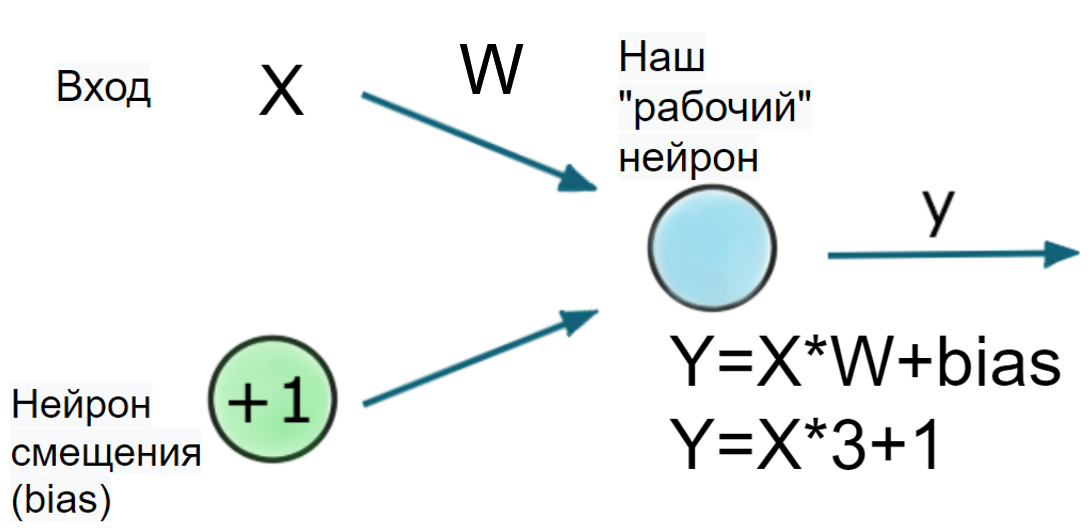

Рис. 5. Структура нейросети для решения уравнения Y = 3X + 1

В зависимости от сложности решаемых задач, количество нейронов на входных/выходных слоях и на скрытых слоях (на Рис. 5) может различаться. Нейроны смещения есть только на скрытых слоях – по 1 нейрону смещения на весь скрытый слой. Слои всегда полносвязные – все нейроны связаны между собой весом, но вес может быть нулевым.

Каждый входной сигнал умножается на вес, а затем подается на каждый нейрон следующего слоя. Далее нейроны суммируют эти взвешенные сигналы, а затем умножают их сумму на функцию активации, добавляют смещение и передают сигнал на каждый нейрон следующего слоя (через новые веса связей).

Смещение задается только для всего слоя целиком. Нейроны смещения по умолчанию включены, но их можно отключить. Обычно про наличие нейронов смещения отдельно не упоминают.

Слои, несущие основную функциональность, часто называют скрытыми слоями.

Для решения данной задачи (Y = 3X + 1) достаточно сети с 1 нейроном на скрытом слое. Выведем полную конфигурацию первого слоя нейронной сети, а также график зависимости ошибки обучения от эпохи обучения (Рис. 6):

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline

print(history.history.keys())

plt.title('Изменение метрики обучения "ошибка" в зависимости от итерации обучения\n')
plt.xlabel('Итерация обучения, или эпоха (Epoch)')
plt.ylabel('Средне-квадратичная ошибка\n(mean_squared_error)')
plt.plot(history.history['loss'])

model.get_config()['layers'][1]

Рис. 6. Метрика «ошибка обучения» для Y= 3X + 1

#### Ошибки (MSE, RMSE и MAE)

Для вычисления среднеквадратической ошибки (`MSE`) все отдельные остатки регрессии возводятся в квадрат, суммируются, сумма делится на общее число ошибок (формула 31):

| $$MSE = \frac{1}{n}\sum_{i = 1}^{n}\left( Y_{i} - {\widehat{Y}}_{i} \right)^{2}$$ | (31) |
|:----------------------------------------------------------------------------------|------|

где: *n*–общее число ошибок, *Y*<sub>*i*</sub>–реальное значение прогнозируемой переменной (или вектора переменных), *Ŷ*<sub>*i*</sub>–предсказанное значение (или вектор значений).

Так же существует отдельный подвид – $\text{RMSE} = \ \sqrt{\text{MSE}}$, где буква R расшифровывается как root ­– т.е. корень. Удобство RMSE заключается в том, что она измеряется в тех же единицах, что и *Y*<sub>*i*</sub>. В этом смысле она является некоторой альтернативой средней абсолютной ошибки MAE, вычисляемой по формуле, представленной ниже:

| $$\text{MAE} = \frac{1}{n}\sum_{i = 1}^{n}\left| Y_{i} - {\widehat{Y}}_{i} \right|$$ | (32) |
|:-------------------------------------------------------------------------------------|------|

Разница между RMSE и MAE заключается в том, что первая метрика придает большим выбросам относительно больший вес, т.к. ошибки возводятся в квадрат, а MAE имеет у всех ошибок одинаковый вес, так как вычисляется линейно (без квадрата). RMSE всегда будет больше или равен MAE; чем больше разница между ними, тем больше дисперсия в отдельных ошибках в выборке. Если RMSE=MAE, то все ошибки имеют одинаковую величину.

Выбор типа ошибки зависит от задачи и критичности ошибок из–за выбросов. Но, пожалуй, по простоте понимания можно упорядочить от простого уровня по пониманию – к сложному в следующем порядке: MAE, RMSE и MSE. Т.к. первые два измеряются в тех же размерностях, что и предсказанное значение – например, можно утверждать, что если предсказанное число равно 20, а RMSE или MAE равно 2 (а MSE = RMSE <sup>2</sup> = 4), то в среднем число 20 может отличатся на 2 в ту или иную сторону.

Обычно при обучении нейронных сетей используют MSE как функцию потерь, так как при больших ошибках на начальном этапе обучения, процесс обучения выполняется быстрее. При оценке же нагляднее использовать RMSE.

Приведем пример вычисления среднеквадратичной ошибки (MSE) при помощи функциональности `keras`. Вычислим MSE для реальных значений `y_true` и предсказанных `y_pred`[6]:

[6] <span>&#9757;&#128578;</span> Данные значения не имеют ничего общего с рассматриваемым в данном разделе примером. Просто абстрактный пример. Таким же образом вычисляется MSE в процессе обучения или оценивания нейросети.

In [ ]:
y_true = [[0., 1.], [0., 0.]]
y_pred = [[1., 1.], [1., 0.]]
mse = tf.keras.losses.MeanSquaredError()
mse(y_true, y_pred).numpy()

Вычисление значения MSE=0.5 осуществляется представленным ниже способом:

In [ ]:
#**-оператор возведения в степень
((1-0)**2+(1-1)**2+(1-0)**2+(0-0)**2)/4

Визуализируем различие между обучающей выборкой и предсказанными для входных данных из диапазона [-1;5) значениями:

In [ ]:
x_pred = []
y_pred = []
for var in range(-1, 5):
    y_pred.append(model.predict([var])[0][0])
    x_pred.append(var)

import plotly.offline as pyoff
import plotly.graph_objs as go

plot_data = [
    go.Scatter(
        x=x_pred,
        y=y_pred,
        name='Предсказание',
    ),
    go.Scatter(
        x=xs,
        y=ys,
        name='Реальные данные',
    )
]

plot_layout = go.Layout(
    xaxis={"type": "linear"},
    title=
    'График по реальным параметрам и график предсказаний (сильно приблизьте, чтобы увидеть ошибку)'
)

fig = go.Figure(data=plot_data, layout=plot_layout)
pyoff.iplot(fig)

Рис. 7. Сравнение реальных данных с предсказанными для Y = 3X +1

График является интерактивным, т.к. выводится при помощи `plotly`. Вы можете увеличить масштаб («приблизить»), чтобы лучше разглядеть отличия двух графиков.

Набор данных, содержащий соответствующие друг другу значения входных параметров и выходных, называют обучающей выборкой (когда речь про обучение с учителем). Но часто такой набор разделяют с некоторым соотношением, чтобы получить часть данных для обучения, и условно независимую часть данных для оценки точности нейронной сети.

Обычно, в обучающую выборку включают 80% всего датасета, а оставшуюся часть используют как тестовую. В данном случае мы не создаем отдельную тестовую выборку. Это не совсем корректно, но для текущего графика это не сильно принципиально. А вот оценку точности модели при помощи метода `model.evaluate()`, которую ранее мы использовали, следовало бы проводить на отдельном тестовом наборе данных. Но для этого тестовый датасет сперва нужно было бы создать, или получить методом отсечения от обучающего, если бы объем обучающей выборки был достаточен для того, чтобы отсечь от неё часть значений.

В конечном итоге, написан код на языке `Python` при помощи фреймворка `TensorFlow` с надстройкой `Keras`, являющийся реализацией нейросети для решения уравнения Y = 3X + 1.

Далее будет приведено ещё три примера для решения математических уравнений при помощи нейронных сетей. Их код отличается только структурой нейросети (например, есть различия в количестве нейронов или типе функций активации) и предобработкой данных, так как их размерность различается (в том числе это влияет и на размерность входного и выходного слоя нейросети). Код для удобства будет представлен единой ячейкой `Jupyter`.

### Пример 2. Y = 2X

Ниже представлен пример реализации нейронной сети для решения уравнения Y = 2X. Для решения данной функции достаточно 30 нейронов с сигмоидальной функцией активации со 100 эпохами.

Обратите внимание, что в `model.fit()` указан параметр `verbose=0 (c англ. – многословие)`, что означает, что вывод при обучении будет минимальный – не будет выводится информация по каждой эпохе, а выведется только итоговая потеря обучения. По умолчанию – `verbose=1.`

Так же используется метод `Keras_backend.clear_session()`, который необходим для очистки `TensorFlow` и `Keras`, так как ранее в этом же ноутбуке запускалась другая модель, которая уже была обучена. Именно чтобы «забыть все прошлые наработки», и работать с новой моделью «с чистого листа» и используется данный метод (очищает все графы, веса, начальные условия генератора весов и т.п.).

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import backend as Keras_backend
import matplotlib.pyplot as plt
from tensorflow.keras.utils import plot_model

Keras_backend.clear_session()

model = tf.keras.Sequential([
    keras.layers.Dense(30, input_dim=1, activation='sigmoid'),
    keras.layers.Dense(1, activation='linear')
])

model.compile(optimizer='sgd', loss='mean_squared_error')

xs = np.array([
    -10.0, -9.0, -8.0, -7.0, -6.0, -5.0, -4.0, -3.0, -2.0, -1.0, 0.0, 1.0, 2.0,
    3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0
], dtype=float)

def func(x):
    return 2 * x

ys = np.array([func(x) for x in xs])

print('xs:', xs)
print('ys:', ys)

history = model.fit(xs, ys, epochs=100, verbose=0)
print("Loss:", model.evaluate(xs, ys, verbose=0))

plt.title('Изменение метрики обучения "ошибка" в зависимости от итерации обучения\n')
plt.xlabel('Итерация обучения (Epoch)')
plt.ylabel('Среднеквадратичная ошибка (mean_squared_error)')
plt.plot(history.history['loss'])
plt.grid()
plt.show()

# --- Предсказание
predict_value = 8.0
print('Число для предсказания: ', predict_value)

input_array = np.array([[predict_value]], dtype=np.float32)
prediction = model.predict(input_array, verbose=0)[0][0]
print('Предсказание: ', prediction)

real = func(predict_value)
if real * 0.9 < prediction < real * 1.1:
    print('✅ Точность для predict_value больше 90% — УДОВЛЕТВОРИТЕЛЬНО.')
else:
    print('❌ Точность ниже 90% — НЕ удовлетворительно.')

# --- Визуализация модели (сохранится в файл)
plot_model(model,
           to_file='model_example2.png',
           show_shapes=True,
           show_layer_names=True,
           rankdir='TB',
           expand_nested=False,
           dpi=96)


Рис. 8. Структура нейросети для решения уравнения Y = 2X

Рис. 9. Метрика «ошибка обучения» для Y = 2X

#### Вывод весов

Выведем веса обученной нейросети при помощи кода ниже, чтобы разобраться более основательно как работает такая математическая абстракция, как «нейронная сеть». Если представить графически данную нейросеть, то получится результат похожий на Рис. 10.

In [ ]:
for layer in model.layers:
    weights = layer.get_weights()  # list of numpy arrays
print(f'Веса: {np.around(weights[0],1)}')
print(f'Нейрон смещения: {np.around(weights[1],1)}')


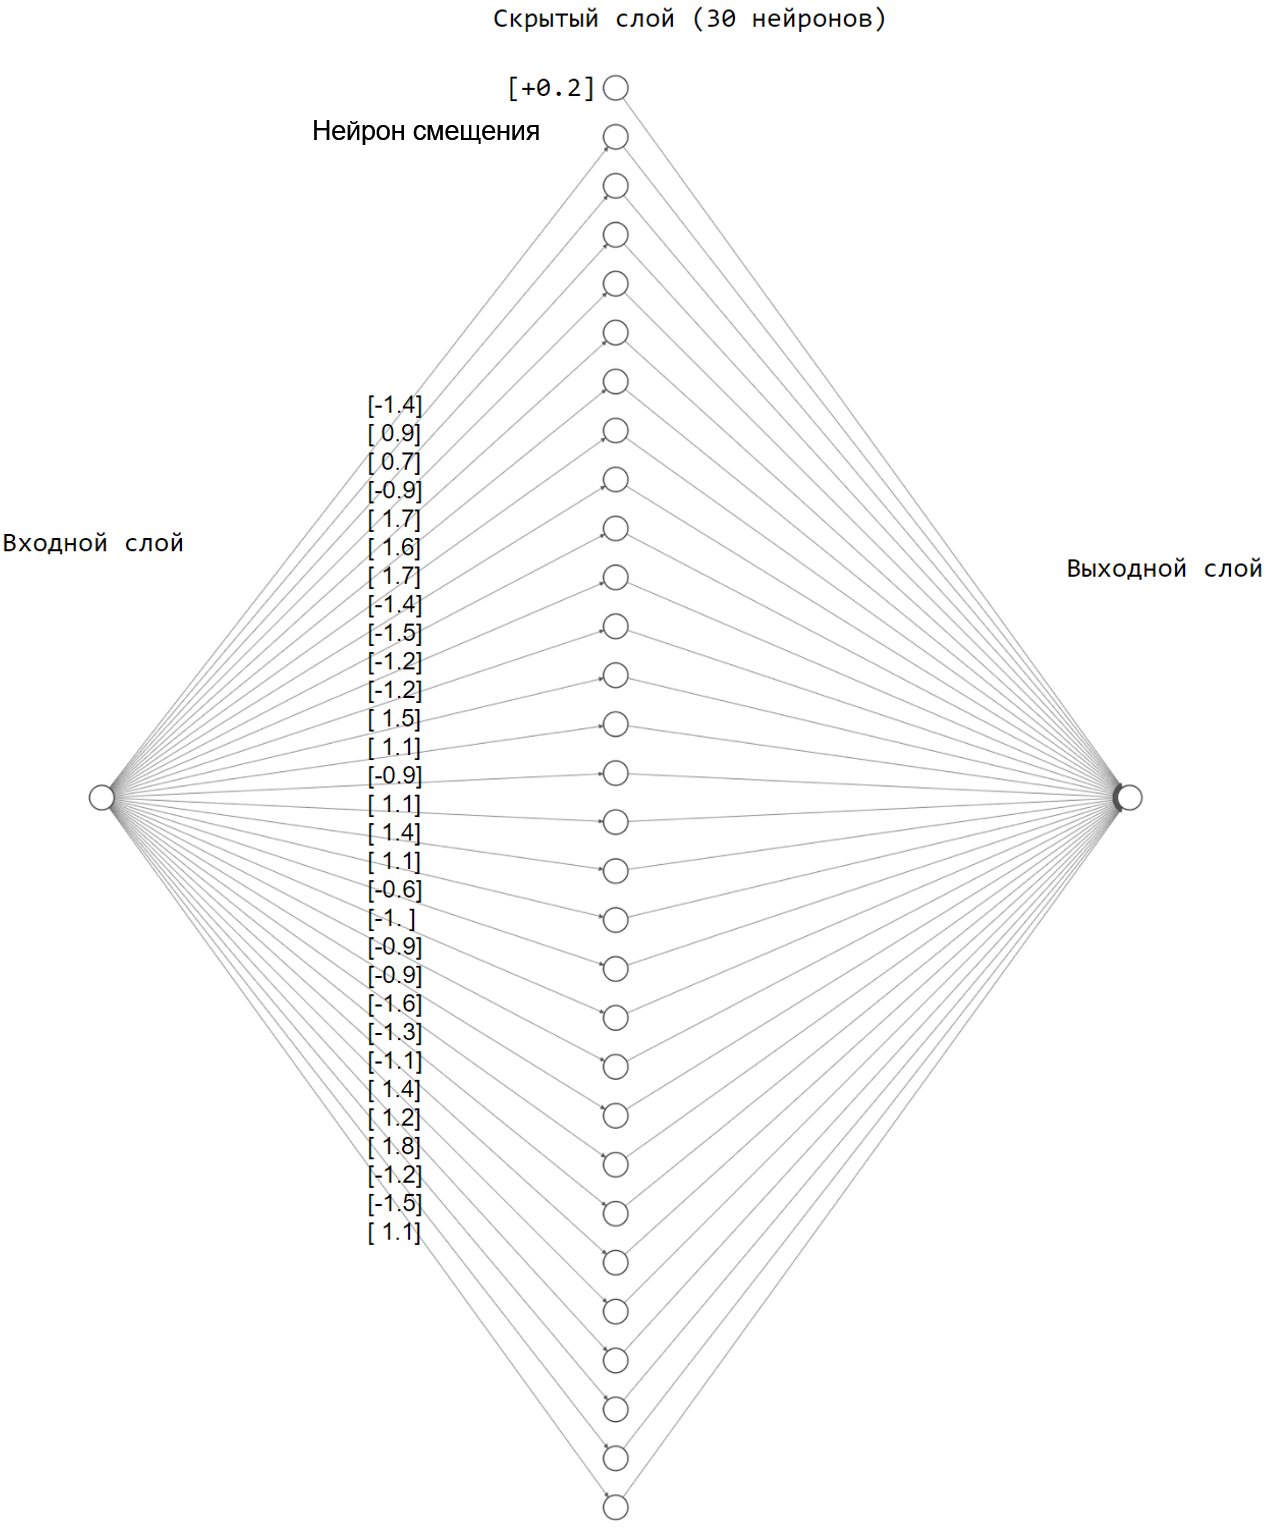

Рис. 10. Структура нейросети для уравнения Y = 2X

Числа на картинке (Рис. 10) могут не соответствовать значениям весов из вывода выше, потому что распределение весов случайно, и в любом случае–можно сменить количество эпох обучения, тогда числа тем более будут отличатся.

Также числа могут быть разными даже при запуске с разных компьютеров! Поэтому картинка представлена просто для понимания, а не для поиска в ней ошибок. В любом случае, порядок нейронов и их весов разницы не имеет – сеть в конечном итоге будет работать одинаково.

Классическое представление структуры нейронных сетей выглядит именно так – изображают нейроны, обозначенные кружками, выстраивают их в вертикальные слои, и при помощи весов (линий) связывают нейроны между собой.

Как уже говорилось, обычно нейронные сети всегда полносвязные (иначе было бы сложно их обучать), а скрытыми (или промежуточными) слоями называют все слои, которые не являются входными или выходными.

Скрытыми слои называются по тому, что их входы и выходы условно неизвестны или действительно неизвестны для внешних по отношению к нейронной сети программам и пользователю. Грубо говоря скрытые слои – это черный ящик, который был обучен и его остается только использовать, подавая входные значения и получая выходные.

Выведем график реальных и предсказанных значений (Рис. 11):

In [ ]:
import numpy as np
import plotly.offline as pyoff
import plotly.graph_objs as go

x_pred = []
y_pred = []

for var in range(-10, 11):
    input_array = np.array([[var]], dtype=np.float32)
    prediction = model.predict(input_array, verbose=0)[0][0]
    y_pred.append(prediction)
    x_pred.append(var)


plot_data = [
    go.Scatter(
        x=x_pred,
        y=y_pred,
        name='Предсказание',
    ),
    go.Scatter(
        x=xs,
        y=ys,
        name='Реальные данные',
    )
]

plot_layout = go.Layout(
    xaxis={"type": "linear"},
    title='График по реальным параметрам и график предсказаний (сильно приблизьте, чтобы увидеть ошибку)'
)

fig = go.Figure(data=plot_data, layout=plot_layout)
pyoff.iplot(fig)


Рис. 11. Сравнение реальных данных с предсказанными для Y = 2X

На графике из вывода кода выше (Рис. 11) видно, что расхождения реальных и предсказанных значений довольно велики. Но при написании данной книги не стояло цели представить оптимальные для решения поставленных задач структуры нейросетей. Представлены лишь некоторые опорные примеры, на основе которых можно самостоятельно разработать оптимальные решения.

### Пример 3. Y = sin(X)

Ниже представлен пример реализации нейронной сети для решения уравнения Y = sin(X). Для решения данной функции достаточно 50 нейронов с `relu` функцией активации с 300 эпохами.

In [ ]:
Keras_backend.clear_session()  #для очистки нумерации слоев в Keras

model = tf.keras.Sequential([
    keras.layers.Dense(50, input_dim=1,
                       activation='relu'),  #функция активации "выпрямитель"
    keras.layers.Dense(1, input_dim=50,
                       activation='linear')  #данный слой необходим,
    #чтобы из множества выходов сделать лишь один, линейная функция активации
])

sgd = keras.optimizers.SGD(learning_rate=0.01, momentum=0.9,
                           nesterov=True)  #сконфигурируем оптимизатор
#для лучшей оптимизации обучения нейросети для решения функции sin(x)

model.compile(optimizer=sgd, loss='mean_squared_error')

ys = []
xs = np.arange(-2, 2, 0.1)

# importing "math" for mathematical operations
import math  # noqa: E402

def func(x):
    return math.sin(x)

for i in range(len(xs)):
    #yz[i]=func(xz[i])
    ys.append(func(xs[i]))
ys = np.array(ys)

#print('xs:', xs)
#print('ys:', ys)

history = model.fit(xs, ys, epochs=300,
                    verbose=0)  #verbose=0-не печатать ничего
print(model.evaluate(xs, ys))

plt.title(
    'Изменение метрики обучения "ошибка" в зависимости от итерации обучения\n')
plt.xlabel('Итерация обучения, или эпоха (Epoch)')
plt.ylabel('Средне-квадратичная ошибка\n(mean_squared_error)')
plt.plot(history.history['loss'])

predict_value = 1.26

print('Число для предсказания: x=', predict_value, ' y=', func(predict_value))

print('Предсказание: ', model.predict([predict_value]))

if (func(predict_value) * 1.1 > model.predict([predict_value])
        and func(predict_value) * 0.9 < model.predict([predict_value])):
    print('Точность для predict_value больше 10%, что удовлетворительно.')
else:
    print('Точность для predict_value меньше 10%, что НЕ удовлетворительно.')

plot_model(model,
           to_file='model_example3.png',
           show_shapes=True,
           show_layer_names=True,
           rankdir='TB',
           expand_nested=False,
           dpi=96)

x_pred = []
y_pred = []
for var in range(-20, 21):
    y_pred.append(model.predict([var / 10])[0][0])
    x_pred.append(var / 10)

plot_data = [
    go.Scatter(
        x=x_pred,
        y=y_pred,
        name='Предсказание',
    ),
    go.Scatter(
        x=xs,
        y=ys,
        name='Реальные данные',
    )
]

plot_layout = go.Layout(
    xaxis={"type": "linear"},
    title=
    'График по реальным параметрам и график предсказаний (сильно приблизьте, чтобы увидеть ошибку)'
)

fig = go.Figure(data=plot_data, layout=plot_layout)
pyoff.iplot(fig)

Рис. 12. Сравнение реальных данных с предсказанными для Y = sin(X)

Рис. 13. Метрика «ошибка обучения» для Y = sin(X)

### Пример 4. Y = (K+X)*X

Ниже представлен пример реализации нейронной сети для решения уравнения Y = (K+X)*X. Для решения данной функции достаточно 20 нейронов с сигмоидальной функцией активации с 300 эпохами.

In [ ]:
Keras_backend.clear_session()  #для очистки нумерации слоев в Keras

model = tf.keras.Sequential([
    #keras.layers.Flatten(input_shape=(2,)),
    keras.layers.Dense(units=20, input_dim=2, activation='sigmoid'),
    #keras.layers.Dense(8, input_dim=20, activation='sigmoid'),
    keras.layers.Dense(1, activation='linear'
                       )  #данный слой необходим, чтобы из множества выходов
    #сделать лишь один
])

sgd = keras.optimizers.SGD(learning_rate=0.01, momentum=0.9,
                           nesterov=True)  #сконфигурируем оптимизатор
#для лучшей оптимизации обучения нейросети для решения функции sin(x)

model.compile(optimizer=sgd, loss='mean_squared_error')

ys = []

xs = np.array([
    -5.9, -5.1, -4.9, -4.1, -3.9, -3.1, -2.9, -2.1, -1.9, -0.1, 0.9, 0.1, 1.9,
    1.1, 2.9, 2.1, 3.9, 3.1, 4.9, 4.1, 5.9
],
              dtype=float)

ks = np.array([
    -5.5, -5.0, -4.5, -4.0, -3.5, -3.0, -2.5, -2.0, -1.0, -0.5, 0.0, 0.5, 1.0,
    1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0
],
              dtype=float)

def func(k, x):
    return (k + x) * x

for i in range(len(xs)):
    ys.append(func(ks[i], xs[i]))
ys = np.array(ys)

#print('xs:', xs)
#print('ks:', xs)
#print('ys:', ys)

IN = np.array([])
IN = np.column_stack(
    (xs, ks)
)  #делает из двух массивов один, где элементы парные [[x1,k1][x2,k2]...], #именно без запятых между массивами. Это не то же самое, что списки в питоне
#print('IN:', IN)

history = model.fit(IN, ys, epochs=300,
                    verbose=0)  #verbose=0-не печатать ничего

plt.title(
    'Изменение метрики обучения "ошибка" в зависимости от итерации обучения\n')
plt.xlabel('Итерация обучения, или эпоха (Epoch)')
plt.ylabel('Средне-квадратичная ошибка\n(mean_squared_error)')
plt.plot(history.history['loss'])

print(model.evaluate(IN, ys))

k = 2.0
x = 3.0
predict_value = np.array([[x, k]])

print('Числa для предсказания: k=', k, ' x=', x)
#print('predict_value: ',predict_value )

print('Предсказание: ', model.predict(predict_value))

if (func(k, x) * 1.1 > model.predict(predict_value)
        and func(k, x) * 0.9 < model.predict(predict_value)):
    print('Точность для predict_value больше 10%, что удовлетворительно.')
else:
    print('Точность для predict_value меньше 10%, что НЕ удовлетворительно.')

plot_model(model,
           to_file='model_example4.png',
           show_shapes=True,
           show_layer_names=True,
           rankdir='TB',
           expand_nested=False,
           dpi=96)
x_pred = []
y_pred = []
k_pred = []

for var in range(-60, 61):
    y_pred.append(model.predict(np.array([[var / 10, var / 10]]))[0][0])
    x_pred.append(var / 10)
    k_pred.append(var / 10)

plot_data = [
    go.Scatter(
        x=x_pred,
        y=y_pred,
        name='Предсказание',
    ),
    go.Scatter(
        x=xs,
        y=ys,
        name='Реальные данные',
    )]

plot_layout = go.Layout(
    xaxis={"type": "linear"},
    title='График по реальным параметрам и график предсказаний (сильно приблизьте, чтобы увидеть ошибку)')

fig = go.Figure(data=plot_data, layout=plot_layout)
pyoff.iplot(fig)

Рис. 14. Сравнение реальных данных с предсказанными для Y = (K+X)*X

Рис. 15. Метрика «ошибка обучения» для Y = (K+X)*X

### Настройки оптимизатора

Обратите внимание, что в 3 и 4 примерах было произведена настройка оптимизатора при помощи представленного ниже кода:

In [ ]:
sgd = keras.optimizers.SGD(learning_rate=0.01, momentum=0.9,
                           nesterov=True)  #сконфигурируем оптимизатор
#для лучшей оптимизации обучения нейросети для решения функции sin(x)

model.compile(optimizer=sgd, loss='mean_squared_error')

Здесь указывается три параметра:

-   `learning_rate` (c англ. скорость обучения) ­– Влияет на скорость обучения наибольшим образом. По умолчанию `learning_rate=0.01`.

На каждой эпохе обучения происходит изменение весов с некоторым шагом, а именно – с шагом, равным `learning_rate`. И веса подбираются таким образом (меняясь в большую и меньшую сторону), чтобы ошибка была минимальной. Но чем меньше шаг, тем больше потребуется эпох обучения.

И если шаг слишком маленький, то мы можем попасть в локальный минимум ошибки[7] – это ситуация, когда размера шага недостаточно, чтобы при обучении на основе ошибки веса изменились значительно и тем самым были перепробованы действительно все веса, а не только какая–либо их узкая часть.

[7] <span>&#9757;&#128578;</span> Т.к. нейронные сети обучаются при помощи метода обратного распространения ошибки. См. информацию, доступную по url: [<span custom-style="Hyperlink">https://ru.wikipedia.org/wiki/Метод_обратного_распространения_ошибки</span>](https://ru.wikipedia.org/wiki/Метод_обратного_распространения_ошибки).

Слишком маленькая скорость обучения заставляет алгоритм сходиться очень долго и «застревать» в локальных минимумах, слишком большая — «пролетать» узкие глобальные минимумы или вовсе расходиться.

Но на самом деле для эффективной борьбы с локальными минимумами существует и другой параметр – момент.

-   `momentum` (момент) – ускоряет градиентный спуск в соответствующем направлении и гасит колебания. По умолчанию `momentum=0`.

Градиентный спуск – метод нахождения локального минимума или максимума функции с помощью движения вдоль градиента. Говоря более простым языком: это некий алгоритм оптимизации, который позволяет быстрее обучать нейронную сеть, не перебирая все возможные варианты весов, а «двигаясь по тем вариантам смены весов», которые дают наибольшую скорость снижения ошибки.

-   nesterov – применять ли ускоренные градиенты Нестерова. Это одно из доступных улучшений метода `SGD` (градиентного спуска), увеличивающие скорость сходимости. По умолчанию `nesterov=false` (т.е. отключено).

Изучить влияние настроек оптимизатора предлагается самостоятельно или использовать значения по умолчанию. Но стоит отметить, что настройки оптимизатора значительно влияют на скорость обучения (количество эпох) и итоговую точность нейросети (ошибку).

В завершение занятия удалим все созданные файлы, чтобы не засорять память компьютера:

In [ ]:
import os

files = ['model_example1.png', 'model_example2.png', 'model_example3.png', 'model_example4.png']
for f in files:
    if os.path.isfile(f): # если файл существует
        os.remove(f)

### Контрольные задания и вопросы

1.  Что дает использование высокоуровневой библиотеки `Keras`, являющейся надстройкой над `TensorFlow`?

2.  Что такое функции потерь и алгоритм оптимизатора? Какие функции активации доступны в библиотеке `Keras`? Перечислите 2–3 любых и приведите примеры использования.

3.  Чем определяется количество входов/выходов у нейросети?

4.  Какова последовательность определения, обучения, использования нейросетевой модели `TensorFlow` c надстройкой `Keras`? Опишите кратко алгоритм работы программных кодов (на основе материалов занятия).

5.  Верно ли утверждение: если набор данных слишком вариативен или количество обучающих примеров слишком велико, то сеть станет обладать плохой интерполирующей способностью и будет «запоминать» ответы?

6.  Реализуйте при помощи нейронной сети (на базе `TensorFlow` `Keras`) решение одного из десяти математических уравнений, представленных в таблице ниже (Таблица 3). Необходимо по примерам, представленным в занятии, создать, обучить и протестировать нейросеть для решения данного математического уравнения.

Таблица 3. Варианты индивидуальных заданий

<table>
<colgroup>
<col style="width: 25%" />
<col style="width: 25%" />
<col style="width: 25%" />
<col style="width: 25%" />
</colgroup>
<thead>
<tr class="header">
<th>

<strong>№ варианта</strong>

</th>
<th>

<strong>Уравнение</strong>

</th>
<th>

<strong>№ варианта</strong>

</th>
<th>

<strong>Уравнение</strong>

</th>
</tr>
</thead>
<tbody>
<tr class="odd">
<td>

1

</td>
<td>

Y=x+2

</td>
<td>

2

</td>
<td>

Y=5x

</td>
</tr>
<tr class="even">
<td>

3

</td>
<td>

Y=7x+2

</td>
<td>

4

</td>
<td>

Y=12х

</td>
</tr>
<tr class="odd">
<td>

5

</td>
<td>

Y=0.5х

</td>
<td>

6

</td>
<td>

Y=2sinx

</td>
</tr>
<tr class="even">
<td>

7

</td>
<td>

Y=3cosx

</td>
<td>

8

</td>
<td>

Y=x/2

</td>
</tr>
<tr class="odd">
<td>

9

</td>
<td>

Y=x<sup>2</sup>+1

</td>
<td>

10

</td>
<td>

Y=8sinx

</td>
</tr>
</tbody>
</table>

Выбор архитектуры нейронной сети (количество слоев, методы оптимизации и функции активации) выполняется самостоятельно методом подбора. Цель работы – создать нейронную сеть, количество эпох обучения которой не превышает 500, количество нейронов на каждом слое – не более 50, количество слоев – не более 2. Количество обучающих примеров не должно быть меньше 20 штук, точность нейронной сети – не хуже ±10%.

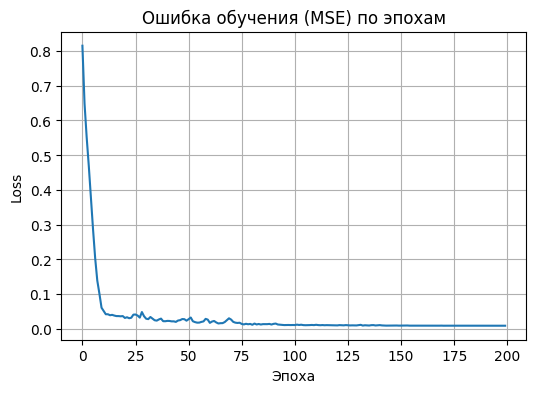

Финальный Loss: 0.0085

Предсказание для x = 1.0: 1.7560 (ожидалось: 1.6829)
✅ Точность выше 90% — УДОВЛЕТВОРИТЕЛЬНО.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import backend as K
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import plot_model
import plotly.offline as pyoff
import plotly.graph_objs as go
import warnings

# отключение ошибок о старой версии функции из библиотеки
warnings.filterwarnings('ignore')
tf.get_logger().setLevel('ERROR')


K.clear_session()

# Определяем модель (≤2 слоя, ≤50 нейронов)
model = keras.Sequential([
    keras.Input(shape=(1,)),
    keras.layers.Dense(50, activation='tanh'),
    keras.layers.Dense(1, activation='linear')
])

# Компилируем с Adam и MSE
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.01),
    loss='mean_squared_error'
)

# Целевая функция
def func(x):
    return 2 * np.sin(x)

# Генерируем обучающие данные на одном периоде sin:
raw_xs = np.linspace(-np.pi, np.pi, 200, dtype=np.float32)
xs = raw_xs.reshape(-1, 1)
ys = func(raw_xs).reshape(-1, 1)

# ранняя остановка + снижение LR на плато
early_stop = EarlyStopping(monitor='loss', patience=20, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='loss', factor=0.5, patience=10, min_lr=1e-5)

# Обучаем
history = model.fit(
    xs, ys,
    epochs=200,
    batch_size=16,
    verbose=0,
    callbacks=[early_stop, reduce_lr]
)

# График MSE по эпохам
plt.figure(figsize=(6,4))
plt.plot(history.history['loss'])
plt.title('Ошибка обучения (MSE) по эпохам')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.grid()
plt.show()

# Проверка на x = 1.0
x_val = 1.0
predicted = model.predict(np.array([[x_val]], dtype=np.float32), verbose=0)[0][0]
true_val  = func(x_val)

print(f"Финальный Loss: {model.evaluate(xs, ys, verbose=0):.4f}")
print(f"\nПредсказание для x = {x_val:.1f}: {predicted:.4f} (ожидалось: {true_val:.4f})")
if true_val * 0.9 <= predicted <= true_val * 1.1:
    print("✅ Точность выше 90% — УДОВЛЕТВОРИТЕЛЬНО.")
else:
    print("❌ Точность ниже 90% — НЕ удовлетворительно.")

# Визуализация архитектуры
plot_model(
    model,
    to_file='model_sin_final.png',
    show_shapes=True,
    show_layer_names=True,
    dpi=96
)

# Сравнение по всей области
x_plot = np.linspace(-np.pi, np.pi, 300, dtype=np.float32)
y_real = func(x_plot)
y_pred  = model.predict(x_plot.reshape(-1,1), verbose=0).flatten()

plot_data = [
    go.Scatter(x=x_plot, y=y_pred, name='Предсказания'),
    go.Scatter(x=x_plot, y=y_real, name='Реальная функция'),
]
layout = go.Layout(
    title='Сравнение Y=2·sin(x) и предсказания нейросети',
    xaxis={'title':'x'},
    yaxis={'title':'Y'}
)
fig = go.Figure(data=plot_data, layout=layout)
pyoff.init_notebook_mode(connected=True)
pyoff.iplot(fig)